# Data loading and exploration

Wczytano zbiór danych dotyczący samobójstw na świecie oraz podstawowe biblioteki potrzebne do analizy danych i wizualizacji.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

suicide = pd.read_csv('master.csv')
suicide.head()


,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


Sprawdzono strukturę zbioru danych, liczbę rekordów, typy zmiennych oraz występowanie brakujących wartości.

In [3]:
suicide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


Zbiór zawiera 27820 obserwacji i 12 zmiennych. Większość kolumn nie zawiera brakujących danych, wyjątkiem jest kolumna „HDI for year”.

Sprawdzono najczęściej występujące wartości w zmiennych kategorycznych, takich jak kraj, płeć, wiek i generacja.

In [4]:
# sprawdzenie braków i wartości kategorii
for col in ['country','sex','age','generation']:
    print('\n', col)
    print(suicide[col].value_counts().head())



 country
country
Austria        382
Mauritius      382
Netherlands    382
Iceland        382
Brazil         372
Name: count, dtype: int64

 sex
sex
male      13910
female    13910
Name: count, dtype: int64

 age
age
15-24 years    4642
35-54 years    4642
75+ years      4642
25-34 years    4642
55-74 years    4642
Name: count, dtype: int64

 generation
generation
Generation X       6408
Silent             6364
Millenials         5844
Boomers            4990
G.I. Generation    2744
Name: count, dtype: int64


Dane są równomiernie rozłożone pomiędzy płciami i grupami wiekowymi, co pozwala na bardziej wiarygodną analizę.

Wyznaczono podstawowe statystyki opisowe dla wszystkich zmiennych.

In [5]:
suicide.describe(include='all')

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
count,27820,27820.000000,27820,27820,27820.000000,2.782000e+04,27820.000000,27820,8364.000000,27820,27820.000000,27820
unique,101,NaN,2,6,NaN,NaN,NaN,2321,NaN,2321,NaN,6
top,Austria,NaN,male,15-24 years,NaN,NaN,NaN,Uzbekistan2014,NaN,"63,067,077,179",NaN,Generation X
freq,382,NaN,13910,4642,NaN,NaN,NaN,12,NaN,12,NaN,6408
mean,NaN,2001.258375,NaN,NaN,242.574407,1.844794e+06,12.816097,NaN,0.776601,NaN,16866.464414,NaN
std,NaN,8.469055,NaN,NaN,902.047917,3.911779e+06,18.961511,NaN,0.093367,NaN,18887.576472,NaN
min,NaN,1985.000000,NaN,NaN,0.000000,2.780000e+02,0.000000,NaN,0.483000,NaN,251.000000,NaN
25%,NaN,1995.000000,NaN,NaN,3.000000,9.749850e+04,0.920000,NaN,0.713000,NaN,3447.000000,NaN
50%,NaN,2002.000000,NaN,NaN,25.000000,4.301500e+05,5.990000,NaN,0.779000,NaN,9372.000000,NaN
75%,NaN,2008.000000,NaN,NaN,131.000000,1.486143e+06,16.620000,NaN,0.855000,NaN,24874.000000,NaN


Średni wskaźnik samobójstw wynosi około 12,8 na 100 tys. mieszkańców, jednak występują duże różnice pomiędzy obserwacjami.

Rozmiar danych: Zbiór zawiera 27 820 wierszy (count)
W kolumnie HDI for year jest jednak tylko 8364 wartości, co oznacza, że występują tam liczne braki danych.

Zmienne kategoryczne: Dane obejmują 101 unikalnych krajów (unique), z czego najczęściej pojawia się Austria (top), oraz 2 płcie (najczęstszy wpis to male).

Zmienne liczbowe: * Badany okres obejmuje lata 1985–2016 (min do max).

Średnia liczba samobójstw w pojedynczym wpisie wynosi ok. 242 (mean), ale odchylenie standardowe (std) wynosi aż 902, co wskazuje na ogromne zróżnicowanie (bardzo skrajne wartości w zależności od wielkości kraju/populacji).

Maksymalna zarejestrowana wartość w kolumnie suicides_no to aż 22 338.

Utworzono histogram przedstawiający rozkład wskaźnika samobójstw na 100 tys. mieszkańców oraz utworzono wykres pudełkowy przedstawiający rozkład wskaźnika samobójstw w różnych grupach wiekowych.

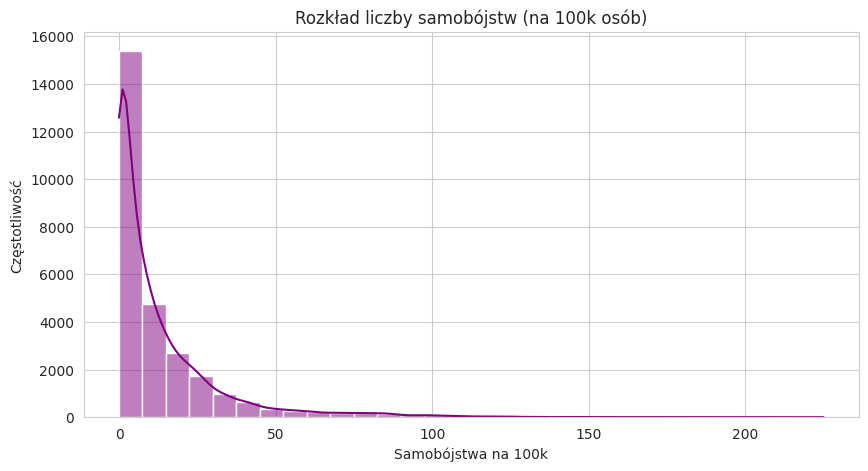

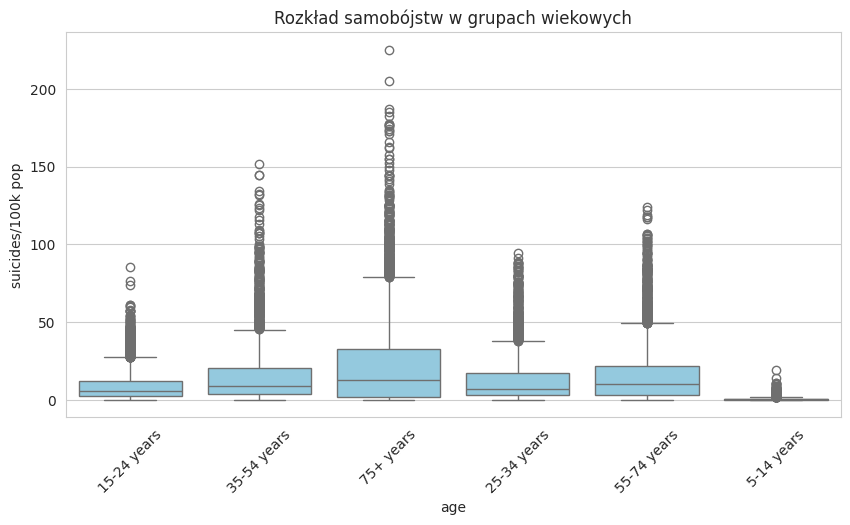

In [6]:
import seaborn as sns
%matplotlib inline
# Ustawienie stylu wykresów
sns.set_style("whitegrid")

# Wykres 1: Rozkład samobójstw na 100k mieszkańców (to jest najważniejsza kolumna)
plt.figure(figsize=(10, 5))
sns.histplot(suicide['suicides/100k pop'], bins=30, kde=True, color='purple')
plt.title('Rozkład liczby samobójstw (na 100k osób)')
plt.xlabel('Samobójstwa na 100k')
plt.ylabel('Częstotliwość')
plt.show()

# Wykres 2: Liczba samobójstw w zależności od wieku
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=suicide,
    x='age',
    y='suicides/100k pop',
    color='skyblue'
)
plt.title('Rozkład samobójstw w grupach wiekowych')
plt.xticks(rotation=45)
plt.show()

Wynikiem działania kodu są dwa wykresy, które pozwalają wyciągnąć bardzo ważne wnioski o charakterze danych:

Wykres 1 (Fioletowy histogram): Rozkład jest silnie prawostronnie skośny. Oznacza to, że w zdecydowanej większości przypadków (wierszy) współczynnik samobójstw na 100k osób jest bardzo niski (bliski zera), a ekstremalnie wysokie wartości zdarzają się rzadko.

Wykres 2 (Niebieski wykres pudełkowy): Pokazuje rozkład w grupach wiekowych.

Grupa 75+ years wyraźnie wyróżnia się najwyższą medianą oraz najwyższymi wartościami odstającymi (kropki nad pudełkiem), co sugeruje, że w tej grupie problem statystycznie bywa najsilniejszy.

Najniższy współczynnik oraz najmniejszą zmienność widać w najmłodszej grupie: 5-14 years.

## Train - test split

Podzielono dane na zbiór treningowy i testowy w proporcji 80% do 20%.

In [7]:
from sklearn.model_selection import train_test_split

# target = liczba samobójstw na 100k mieszkańców
train_set, test_set = train_test_split(suicide, test_size=0.2, random_state=42)


Dzięki podziałowi możliwe jest wytrenowanie modelu na jednej części danych i obiektywne sprawdzenie jego skuteczności na drugiej.

- Data stratification - zamiast income_cat użyjemy kategorii wieku, ponieważ jest to ważna cecha kategoryczna i dobrze nadaje się do stratification.

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(suicide, suicide["age"]):
    strat_train_set = suicide.loc[train_index]
    strat_test_set = suicide.loc[test_index]


 Pamięci programu powstały dwa nowe, idealnie zbalansowane pod kątem wieku podzbiory danych:

strat_train_set: zbiór, na którym modele będą się uczyć.

strat_test_set: zbiór, który posłuży do ostatecznego, sprawiedliwego przetestowania modeli.

Kod służy do zweryfikowania proporcji grup wiekowych w nowo utworzonym zbiorze treningowym (strat_train_set).

Funkcja .value_counts() zlicza wystąpienia każdej grupy wiekowej, a podzielenie tego wyniku przez całkowitą długość zbioru (len(strat_train_set)) przekształca surowe liczby na wartości procentowe (proporcje ułamkowe).

In [9]:
strat_train_set["age"].value_counts() / len(strat_train_set)

,count
age,
75+ years,0.166876
35-54 years,0.166876
25-34 years,0.166876
15-24 years,0.166831
55-74 years,0.166831
5-14 years,0.165708


Wszystkie grupy wiekowe zachowały zbliżony udział procentowy po podziale danych, co zwiększa wiarygodność późniejszych wyników.

In [10]:
# tymczasowo kopiujemy dane treningowe
suicide = strat_train_set.copy()


## Visualisations and correlations

Podzielono kraje na cztery grupy zamożności na podstawie PKB per capita i przedstawiono ich rozkład na wykresie pudełkowym.

Dyskretacja danych (pd.qcut): Dzieli kraje na 4 równe liczebnie grupy (kwantyle) na podstawie ich PKB na mieszkańca (gdp_per_capita ($)) i nadaje im czytelne etykiety: od Najbiedniejsze do Najbogatsze. Wynik zapisuje w nowej kolumnie gdp_group.

Wizualizacja (sns.boxplot): Tworzy wykres pudełkowy, który dla każdej z czterech grup zamożności prezentuje rozkład liczby samobójstw na 100k mieszkańców.

/tmp/ipykernel_717/3815567978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=suicide, x='gdp_group', y='suicides/100k pop', palette='coolwarm')


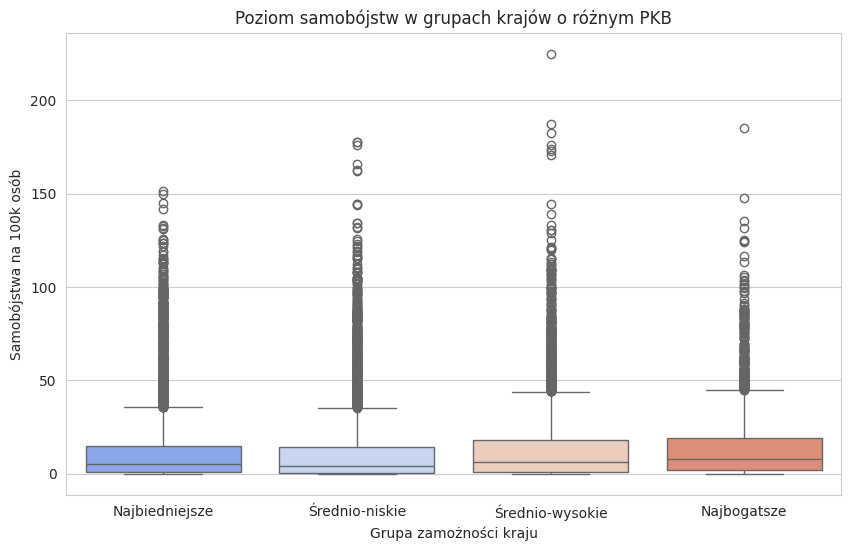

In [11]:
# 1. Tworzymy nową kolumnę: dzielimy kraje na grupy wg PKB
suicide['gdp_group'] = pd.qcut(suicide['gdp_per_capita ($)'], 4, labels=['Najbiedniejsze', 'Średnio-niskie', 'Średnio-wysokie', 'Najbogatsze'])

# 2. Rysujemy wykres pudełkowy (boxplot) - to jest "król" czytelnych wykresów
plt.figure(figsize=(10, 6))
sns.boxplot(data=suicide, x='gdp_group', y='suicides/100k pop', palette='coolwarm')

plt.title('Poziom samobójstw w grupach krajów o różnym PKB')
plt.xlabel('Grupa zamożności kraju')
plt.ylabel('Samobójstwa na 100k osób')
plt.show()

Poziom samobójstw różni się pomiędzy grupami krajów o różnym poziomie PKB, jednak zależność nie jest jednoznaczna.
Wraz ze wzrostem zamożności kraju, poziom (mediana) samobójstw delikatnie rośnie.

Grupa państw Najbogatszych (czerwone pudełko) ma najwyżej położoną linię środkową (medianę) oraz najwyższe "ciało" pudełka (trzeci kwantyl).

Kraje Najbiedniejsze (ciemnoniebieskie pudełko) paradoksalnie wykazują statystycznie najniższy punkt środkowy rozkładu, choć we wszystkich grupach występuje bardzo dużo wysokich wartości odstających (kropki w górę wykresu).

Obliczono współczynniki korelacji pomiędzy zmiennymi liczbowymi.

In [12]:
numeric_data = suicide.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

attributes = ["suicides/100k pop", "gdp_per_capita ($)"]
print(corr_matrix["suicides/100k pop"].sort_values(ascending=False))


suicides/100k pop     1.000000
suicides_no           0.305935
HDI for year          0.077089
population            0.007231
gdp_per_capita ($)    0.000069
year                 -0.040468
Name: suicides/100k pop, dtype: float64


Najsilniejszą dodatnią korelację ze wskaźnikiem samobójstw wykazuje liczba samobójstw (suicides_no). Pozostałe zmienne mają słabe zależności.

Utworzono mapę cieplną przedstawiającą zależności pomiędzy wszystkimi zmiennymi liczbowymi.
Najpierw za pomocą select_dtypes(include=['number']) odrzuca kolumny tekstowe, a metoda .corr() oblicza współczynniki korelacji Persona dla pozostałych cech. Następnie funkcja sns.heatmap generuje mapę ciepła (heatmap).

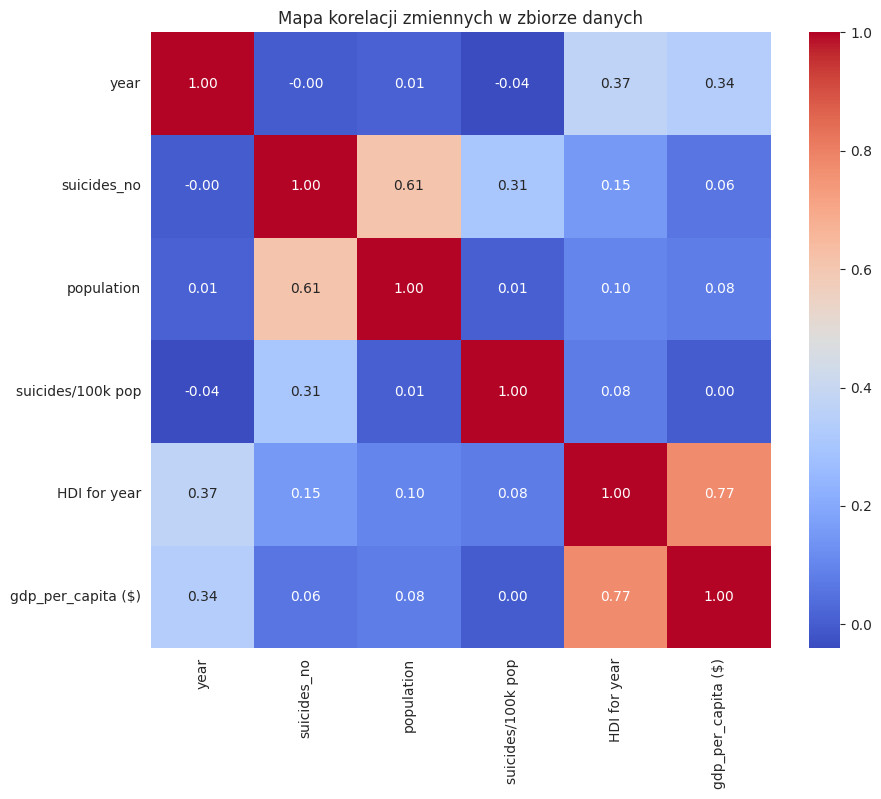

In [13]:
# Obliczamy korelacje między wszystkimi danymi liczbowymi
plt.figure(figsize=(10, 8))
correlation = suicide.select_dtypes(include=['number']).corr()

# Rysujemy mapę ciepła
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa korelacji zmiennych w zbiorze danych')
plt.show()


Silna korelacja dodatnia (0.77): Występuje między gdp_per_capita ($) (PKB na mieszkańca) a HDI for year (Wskaźnik Rozwoju Społecznego). To logiczne – bogatsze kraje mają zazwyczaj wyższy standard życia, edukacji i zdrowia.

Umiarkowana korelacja dodatnia (0.61): Łączy suicides_no (ogólną liczbę samobójstw) z population (wielkością populacji). Wynika to wprost z matematyki – w większych krajach naturalnie dochodzi do większej liczby takich zdarzeń.

Brak korelacji (blisko 0.00): Bardzo ważne jest to, że zmienna suicides/100k pop (współczynnik na 100k mieszkańców, czyli ten niezależny od wielkości kraju) ma bardzo niską korelację z PKB (0.00) oraz z rokiem (-0.04). Oznacza to, że sam upływ lat lub bogactwo kraju nie wykazują prostej, liniowej zależności z tym, jak często dochodzi do samobójstw w przeliczeniu na liczbę ludności.

Utworzono wykres słupkowy porównujący średni wskaźnik samobójstw dla kobiet i mężczyzn.

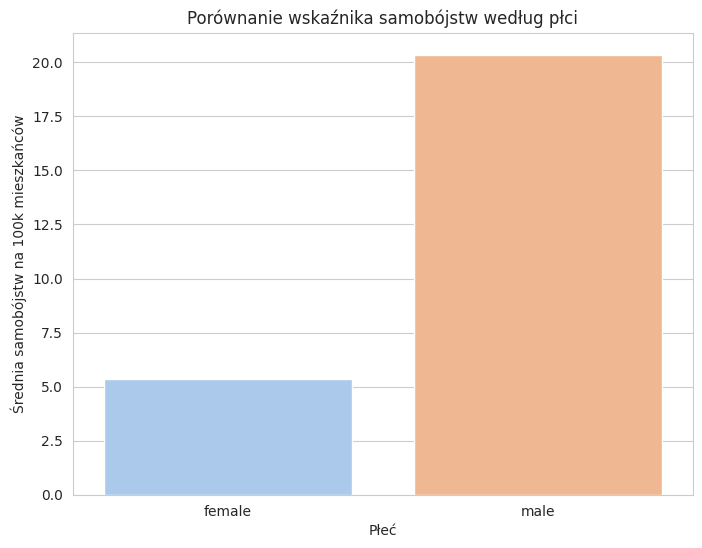

In [14]:
# Wykres słupkowy: Płeć vs Samobójstwa
plt.figure(figsize=(8, 6))

# Używamy barplot, żeby pokazać średnią dla obu płci
sns.barplot(data=suicide, x='sex', y='suicides/100k pop', hue='sex', palette='pastel', legend=False, errorbar=None)

plt.title('Porównanie wskaźnika samobójstw według płci')
plt.xlabel('Płeć')
plt.ylabel('Średnia samobójstw na 100k mieszkańców')
plt.show()


Średni wskaźnik samobójstw jest wyższy wśród mężczyzn niż kobiet.

## Additional columns

In [15]:
suicide.columns

Index(['country', 'year', 'sex', 'age', 'suicides_no', 'population',
       'suicides/100k pop', 'country-year', 'HDI for year',
       ' gdp_for_year ($) ', 'gdp_per_capita ($)', 'generation', 'gdp_group'],
      dtype='object')

Utworzono dodatkową zmienną opisującą relację pomiędzy PKB per capita a wielkością populacji.

In [16]:
# nowa cecha
suicide["gdp_population_ratio"] = (
    suicide["gdp_per_capita ($)"] / suicide["population"]
)

In [17]:
# korelacje po dodaniu cech
numeric_data = suicide.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
corr_matrix["suicides/100k pop"].sort_values(ascending=False)


,suicides/100k pop
suicides/100k pop,1.000000
suicides_no,0.305935
HDI for year,0.077089
population,0.007231
gdp_per_capita ($),0.000069
year,-0.040468
gdp_population_ratio,-0.046059


Nowa cecha nie wykazuje silnej korelacji ze wskaźnikiem samobójstw, jednak może dostarczyć modelowi dodatkowych informacji.

## Label set separation!

Oddzielono zmienną docelową od pozostałych cech wykorzystywanych do uczenia modelu.

In [18]:
suicide_labels = suicide["suicides/100k pop"].copy()

suicide_features = suicide.drop([
    "suicides/100k pop",
    "suicides_no",
    "population"
], axis=1)

Model będzie przewidywał wartość wskaźnika samobójstw na podstawie pozostałych zmiennych.

# Data cleaning - pipeline

Utworzono pipeline automatyzujący przygotowanie danych poprzez uzupełnianie braków, standaryzację oraz kodowanie zmiennych kategorycznych.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_attribs = suicide_features.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs = suicide_features.select_dtypes(exclude=[np.number]).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_attribs)
])

suicide_prepared = full_pipeline.fit_transform(suicide_features)


Dane zostały przekształcone do postaci numerycznej odpowiedniej dla algorytmów uczenia maszynowego.

Sprawdzono rozmiar macierzy po przetworzeniu danych.

In [20]:
suicide_prepared.shape

(22256, 4765)

Liczba cech wzrosła do 4765 w wyniku zastosowania kodowania One-Hot Encoding dla zmiennych kategorycznych.

Kod służy do podejrzenia przetworzonych danych w formie czytelnej tabeli.

Bezpiecznie konwertuje macierz cech (suicide_prepared) na obiekt DataFrame biblioteki pandas. Instrukcja warunkowa if hasattr(..., 'toarray') sprawdza, czy dane są zapisane jako tzw. macierz rzadka (Sparse Matrix – częsty wynik kodowania One-Hot Encoding) i jeśli tak, przekształca ją najpierw w gęstą tablicę NumPy. Na koniec funkcja .head() wyświetla nagłówek, czyli pierwsze 5 wierszy tej tabeli.

In [21]:
pd.DataFrame(suicide_prepared.toarray() if hasattr(suicide_prepared,'toarray') else suicide_prepared).head()

,0,1,2,3,4,5,6,7,8,9,...,4755,4756,4757,4758,4759,4760,4761,4762,4763,4764
0,-0.971787,0.013074,-0.714529,-0.188995,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-1.678953,0.013074,0.380284,0.376229,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.621156,0.013074,-0.348203,0.249190,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.500343,0.013074,-0.681945,-0.182287,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.678268,0.013074,-0.512227,-0.143598,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Wniosek: Tabela pokazuje dane w pełni przygotowane dla algorytmów uczenia maszynowego:

Pierwsze kolumny (0–3) zawierają cechy ciągłe, które zostały poddane skalowaniu (stąd wartości ujemne i dodatnie skupione wokół zera).

Dalsze kolumny (od 4 wzwyż) składają się głównie z zer i jedynek. Jest to bezpośredni rezultat operacji One-Hot Encoding, która przekształciła zmienne kategoryczne (tekstowe) na tysiące pojedynczych kolumn binarnych.

# Linear Regression Model

Wytrenowano model regresji liniowej służący do przewidywania wskaźnika samobójstw.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

lin_reg = LinearRegression()
lin_reg.fit(suicide_prepared, suicide_labels)

suicide_predictions = lin_reg.predict(suicide_prepared)
lin_mse = mean_squared_error(suicide_labels, suicide_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse


np.float64(12.409623605821293)

Średni błąd predykcji modelu wynosi około 12,4 jednostki wskaźnika samobójstw na 100 tys. mieszkańców.

Kod definiuje funkcję pomocniczą o nazwie display_scores, która służy do czytelnego wyświetlania i podsumowywania wyników walidacji modelu (zazwyczaj po użyciu walidacji krzyżowej – Cross-Validation).

In [23]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())


Oceniono model regresji liniowej za pomocą walidacji krzyżowej.

In [24]:
lin_scores = cross_val_score(lin_reg, suicide_prepared, suicide_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)


Scores: [13.5583562  14.90272223 13.95113498 14.07811866 13.59281607 13.11658867
 13.95908591 14.13133931 14.34678676 14.12347003]
Mean: 13.976041881666806
Standard deviation: 0.4597120055910236


Średni błąd RMSE wynosi około 13,98. Niewielkie odchylenie standardowe wskazuje na stabilność modelu.

# Random Forest Regressor Model

Wytrenowano model Random Forest wykorzystujący wiele drzew decyzyjnych.
W definicji modelu wskazano, że ma się on składać z 50 drzew decyzyjnych (n_estimators=50). Metoda .fit() uruchamia proces uczenia algorytmu na pełnym zestawie danych przygotowanych (suicide_prepared) oraz odpowiadających im etykietach/wartościach docelowych (suicide_labels).

In [25]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
forest_reg.fit(suicide_prepared, suicide_labels)


RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

Wynik to reprezentacja graficzna wytrenowanego obiektu. Potwierdza on, że model pomyślnie zakończył proces uczenia (treningu) na podanych danych z zachowaniem określonych parametrów startowych.

Kod służy do ewaluacji (oceny) jakości wytrenowanego wcześniej modelu lasu losowego na danych treningowych.

In [26]:
forest_predictions = forest_reg.predict(suicide_prepared)
forest_mse = mean_squared_error(suicide_labels, forest_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse


np.float64(2.321249463501555)

Bardzo niski błąd na danych treningowych sugeruje bardzo dobre dopasowanie modelu do danych.

Oceniono model Random Forest przy użyciu walidacji krzyżowej.

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

forest_reg = RandomForestRegressor(
    n_estimators=50,
    n_jobs=-1,
    random_state=42
)

forest_scores = cross_val_score(
    forest_reg,
    suicide_prepared,
    suicide_labels,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)

forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)


Scores: [7.21674184 6.31366662 5.43507648 6.33491747 6.15510959]
Mean: 6.291102401826585
Standard deviation: 0.5675406069970208


Średni błąd RMSE wynosi około 6,29, co oznacza znacznie lepszą skuteczność niż w przypadku regresji liniowej.

Obliczono średnią wartość zmiennej przewidywanej.

In [28]:
mean_cost = suicide_labels.mean()
mean_cost


np.float64(12.862489665708123)

Średni wskaźnik samobójstw w zbiorze wynosi około 12,86 na 100 tys. mieszkańców.

Dane porównanie Random forest z Regresją liniową było wykonywane w grupie ćwiczeniowej (walidacje krzyżową zaliczamy do ćwiczeniowej, ponieważ nadal była to ocena na danych treningowych), w dalszej części przejdziemy do ostatecznego sprawdzenia na grupie testowej.

# Grid Search

Przeprowadzono wyszukiwanie najlepszych parametrów modelu Random Forest.

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

param_grid = [
    {
        'n_estimators': [30, 50],
        'max_features': [4, 6],
        'max_depth': [5, 10],
        'min_samples_split': [2, 5]
    }
]

grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(suicide_prepared[:5000], suicide_labels[:5000])

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid=[{'max_depth': [5, 10], 'max_features': [4, 6],
                          'min_samples_split': [2, 5],
                          'n_estimators': [30, 50]}],
             return_train_score=True, scoring='neg_mean_squared_error')

Wynik to komunikat informujący o pomyślnym zakończeniu przeszukiwania i automatycznym dopasowaniu najlepszego modelu.

Ze względu na czas obliczeń Grid Search przeprowadzono na podzbiorze 5000 obserwacji.

In [30]:
grid_search.best_params_

{'max_depth': 10,
 'max_features': 6,
 'min_samples_split': 2,
 'n_estimators': 30}

Najlepszy model uzyskano dla parametrów:

n_estimators = 30

max_depth = 10

max_features = 6

min_samples_split = 2

Parametry te zapewniły najlepszą jakość predykcji spośród testowanych konfiguracji.

In [31]:
grid_search.best_estimator_

RandomForestRegressor(max_depth=10, max_features=6, n_estimators=30, n_jobs=-1,
                      random_state=42)

Wynik pokazuje optymalną konfigurację modelu RandomForestRegressor (regresora lasu losowego), która dała najlepsze rezultaty w testach. Wskazuje konkretne wartości hiperparametrów:

max_depth=10: Maksymalna głębokość pojedynczego drzewa decyzyjnego została ograniczona do 10 poziomów.

max_features=6: Przy każdym podziale drzewa model losowo wybierał maksymalnie 6 cech (kolumn).

n_estimators=30: Las składa się dokładnie z 30 pojedynczych drzew decyzyjnych.

n_jobs=-1: Model został skonfigurowany tak, aby wykorzystać wszystkie dostępne rdzenie procesora do szybszych obliczeń.

random_state=42: Ziarno losowości, które zapewnia identyczne i powtarzalne wyniki przy każdym uruchomieniu kodu.

# Ocena na zbiorze testowym

Wykorzystano najlepszy model wybrany przez Grid Search do oceny na danych testowych.

In [32]:
best_model = grid_search.best_estimator_

# Create the new features on the strat_test_set as well
strat_test_set['gdp_group'] = pd.qcut(strat_test_set['gdp_per_capita ($)'], 4, labels=['Najbiedniejsze', 'Średnio-niskie', 'Średnio-wysokie', 'Najbogatsze'])
strat_test_set["gdp_population_ratio"] = (
    strat_test_set["gdp_per_capita ($)"] / strat_test_set["population"]
)

X_test = strat_test_set.drop([
    "suicides/100k pop",
    "suicides_no",
    "population"
], axis=1)

y_test = strat_test_set["suicides/100k pop"].copy()

X_test_prepared = full_pipeline.transform(X_test)

test_pred = best_model.predict(X_test_prepared)

test_estim = mean_squared_error(y_test, test_pred)
final_rmse = np.sqrt(test_estim)

final_rmse

np.float64(18.283740506414514)

In [33]:
lin_test_pred = lin_reg.predict(X_test_prepared)

lin_test_mse = mean_squared_error(y_test, lin_test_pred)
lin_rmse_test = np.sqrt(lin_test_mse)

print("Regresja liniowa RMSE:", lin_rmse_test)
print("Random Forest RMSE:", final_rmse)

Regresja liniowa RMSE: 13.861623255057138
Random Forest RMSE: 18.283740506414514


Jest to końcowa i najbardziej wiarygodna ocena jakości modelu, ponieważ wykorzystuje dane, których model wcześniej nie widział.

Wynik prezentuje porównanie skuteczności obu modeli za pomocą metryki błędu RMSE.

In [34]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [lin_rmse_test, final_rmse]
})

results

,Model,RMSE
0,Linear Regression,13.861623
1,Random Forest,18.283741


Regresja Liniowa osiągnęła błąd na poziomie ok. 13.86.

Random Forest osiągnął wyższy błąd, wynoszący ok. 18.28.

Wniosek: Ponieważ w przypadku metryki RMSE im niższa wartość, tym lepszy model, w tym eksperymencie lepiej poradziła sobie Regresja Liniowa.